In [247]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.model_selection import GridSearchCV

In [248]:
def plot_svm_decision_boundary(clf, X, y, plot_support=True):

    ax = plt.gca()

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 200)
    yy = np.linspace(ylim[0], ylim[1], 200)

    YY, XX = np.meshgrid(yy, xx)

    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # decision boundary
    ax.contour(XX, YY, Z, levels=[0])

    # margins
    ax.contour(XX, YY, Z, levels=[-1,1], linestyles=["--","--"])

    if plot_support:
        ax.scatter(
            clf.support_vectors_[:,0],
            clf.support_vectors_[:,1],
            s=150,
            facecolors="none"
        )

In [249]:
X1, y1 = make_blobs(centers=2, random_state=50)
y1 = 2*y1 - 1

X2, y2 = make_moons(n_samples=100, noise=0.25, random_state=50)

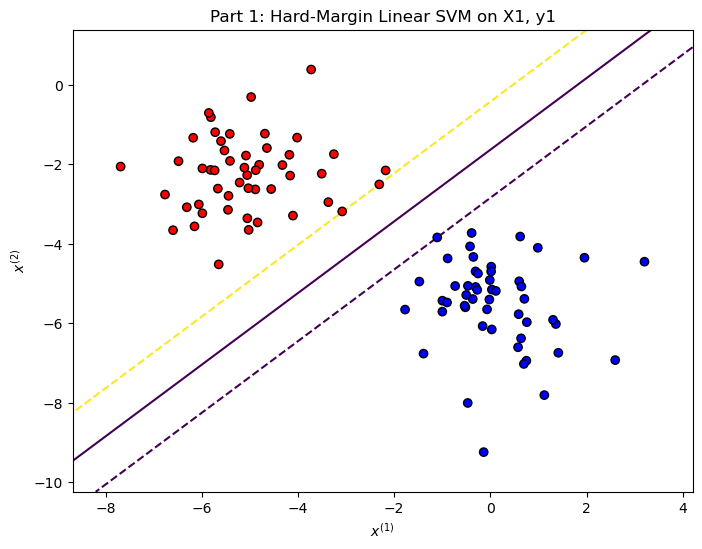

Training accuracy: 1.0000


In [250]:
#problem 1
clf1 = SVC(kernel='linear')
clf1.fit(X1, y1)
plt.figure(figsize=(8, 6))
plt.scatter(X1[:, 0], X1[:, 1], c=y1, cmap='bwr', edgecolors='k', zorder=3)
plt.xlim(X1[:, 0].min() - 1, X1[:, 0].max() + 1)
plt.ylim(X1[:, 1].min() - 1, X1[:, 1].max() + 1)
plot_svm_decision_boundary(clf1, X1, y1)
plt.title("Part 1: Hard-Margin Linear SVM on X1, y1")
plt.xlabel("$x^{(1)}$")
plt.ylabel("$x^{(2)}$")
plt.show()

print(f"Training accuracy: {clf1.score(X1, y1):.4f}")

In [251]:
#problem 2
beta_hat = clf1.coef_[0]
beta0_hat = clf1.intercept_[0]
print("Learned weights beta_hat:", beta_hat)
print("Intercept beta0_hat :", beta0_hat)


sv         = clf1.support_vectors_
sv_indices = clf1.support_
y_sv       = y1[sv_indices]
dual_coefs = clf1.dual_coef_[0]       
alpha_hat  = dual_coefs / y_sv       

print("\nSupport vectors:")
print(sv)
print("\nLagrange multipliers alphas:")
print(alpha_hat)

# Verify stationarity: β̂ = Σ α̂ᵢ yᵢ xᵢ
beta_reconstructed = np.sum(dual_coefs[:, np.newaxis] * sv, axis=0)

print("\nbeta_hat from clf.coef_          :", beta_hat)
print("beta_hat reconstructed from dual :", beta_reconstructed)
print("Max absolute difference    :", np.max(np.abs(beta_hat - beta_reconstructed)))



Learned weights beta_hat: [-0.74427943  0.82511386]
Intercept beta0_hat : 1.3451710165872146

Support vectors:
[[-1.10549315 -3.83942962]
 [-2.31103337 -2.50295853]]

Lagrange multipliers alphas:
[0.6173825 0.6173825]

beta_hat from clf.coef_          : [-0.74427943  0.82511386]
beta_hat reconstructed from dual : [-0.74427943  0.82511386]
Max absolute difference    : 0.0


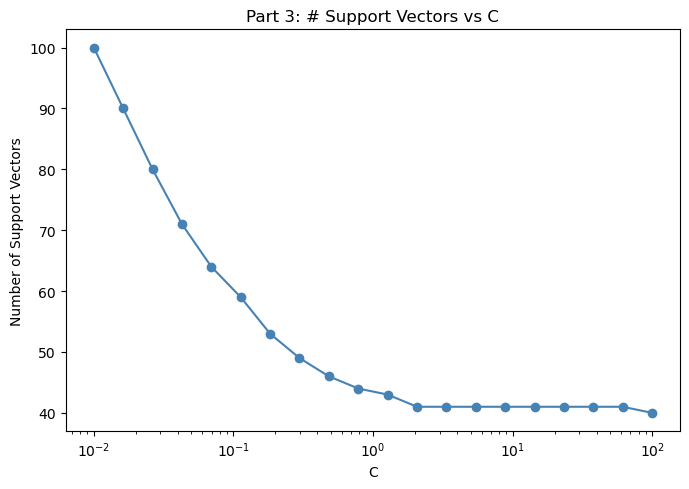

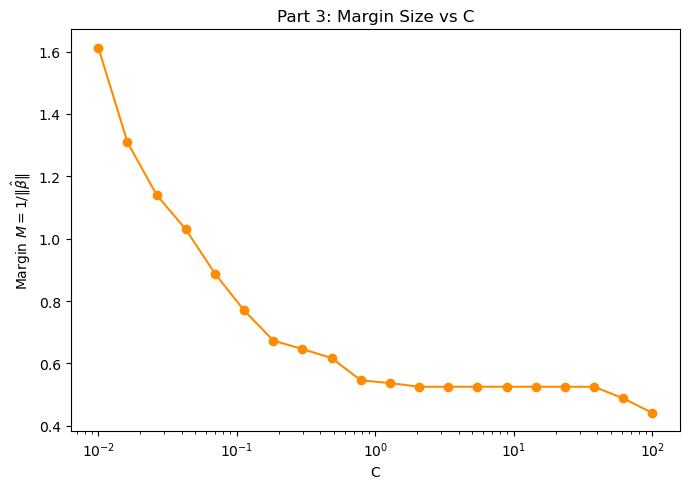

As C increases: fewer support vectors (harder margin), smaller margin.
As C decreases: more support vectors (softer margin), larger margin.


In [252]:
#problem 3
C_values = np.logspace(-2, 2, 20)
n_sv_list   = []
margin_list = []

for C in C_values:
    clf = SVC(kernel='linear', C=C)
    clf.fit(X2, y2)
    n_sv_list.append(clf.support_vectors_.shape[0])
    margin_list.append(1.0 / np.linalg.norm(clf.coef_[0]))


plt.figure(figsize=(7, 5))
plt.semilogx(C_values, n_sv_list, marker='o', color='steelblue')
plt.xlabel("C")
plt.ylabel("Number of Support Vectors")
plt.title("Part 3: # Support Vectors vs C")

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.semilogx(C_values, margin_list, marker='o', color='darkorange')
plt.xlabel("C")
plt.ylabel(r"Margin $M = 1/\|\hat{\beta}\|$")
plt.title("Part 3: Margin Size vs C")

plt.tight_layout()
plt.show()

print("As C increases: fewer support vectors (harder margin), smaller margin.")
print("As C decreases: more support vectors (softer margin), larger margin.")

Best C     : 0.7848
Test Score : 0.8400


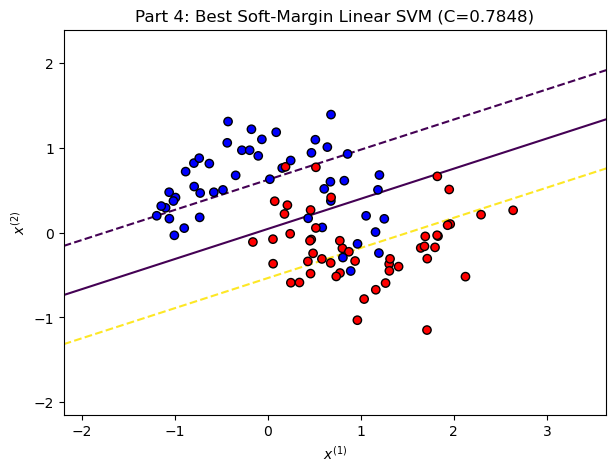

In [253]:
#problem 4
param_grid_linear = {'C': np.logspace(-2, 2, 20)}

gs_linear = GridSearchCV(SVC(kernel='linear'), param_grid_linear)
gs_linear.fit(X2, y2)

best_clf_linear   = gs_linear.best_estimator_
best_C_linear     = gs_linear.best_params_['C']
best_score_linear = gs_linear.best_score_

print(f"Best C     : {best_C_linear:.4f}")
print(f"Test Score : {best_clf_linear.score(X2, y2):.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(X2[:, 0], X2[:, 1], c=y2, cmap='bwr', edgecolors='k', zorder=3)
plt.xlim(X2[:, 0].min() - 1, X2[:, 0].max() + 1)
plt.ylim(X2[:, 1].min() - 1, X2[:, 1].max() + 1)
plot_svm_decision_boundary(best_clf_linear, X2, y2)
plt.title(f"Part 4: Best Soft-Margin Linear SVM (C={best_C_linear:.4f})")
plt.xlabel("$x^{(1)}$")
plt.ylabel("$x^{(2)}$")
plt.show()

Best C      : 37.9269
Best degree : 3
Test Score  : 0.8600


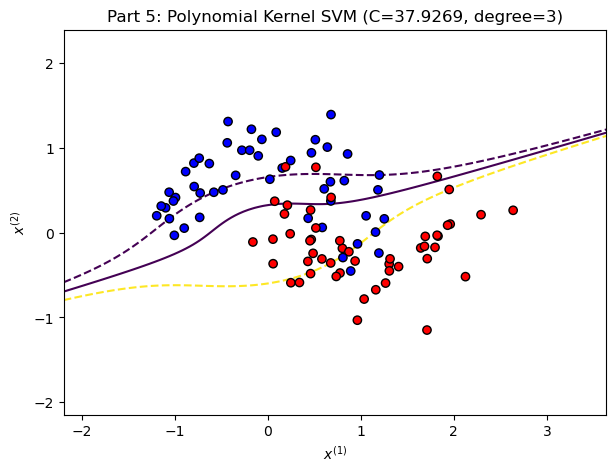

In [254]:
#problem 5
param_grid_poly = {
    'C':      np.logspace(-2, 2, 20),
    'degree': [2, 3, 4, 5]
}

gs_poly = GridSearchCV(SVC(kernel='poly'), param_grid_poly, cv=5, scoring='accuracy')
gs_poly.fit(X2, y2)

best_clf_poly   = gs_poly.best_estimator_
best_C_poly     = gs_poly.best_params_['C']
best_deg_poly   = gs_poly.best_params_['degree']
best_score_poly = gs_poly.best_score_

print(f"Best C      : {best_C_poly:.4f}")
print(f"Best degree : {best_deg_poly}")
print(f"Test Score  : {best_clf_poly.score(X2, y2):.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(X2[:, 0], X2[:, 1], c=y2, cmap='bwr', edgecolors='k', zorder=3)
plt.xlim(X2[:, 0].min() - 1, X2[:, 0].max() + 1)
plt.ylim(X2[:, 1].min() - 1, X2[:, 1].max() + 1)
plot_svm_decision_boundary(best_clf_poly, X2, y2)
plt.title(f"Part 5: Polynomial Kernel SVM (C={best_C_poly:.4f}, degree={best_deg_poly})")
plt.xlabel("$x^{(1)}$")
plt.ylabel("$x^{(2)}$")

plt.show()


Best C      : 0.2976
Best gamma  : 5.4556
Test Score  : 0.9100


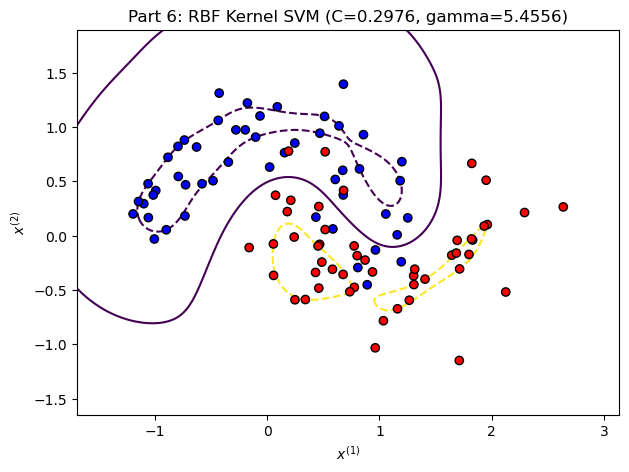

In [255]:
#problem 6
param_grid_rbf = {
    'C':     np.logspace(-2, 2, 20),
    'gamma': np.logspace(-2, 2, 20)
}

gs_rbf = GridSearchCV(SVC(kernel='rbf'), param_grid_rbf)
gs_rbf.fit(X2, y2)

best_clf_rbf   = gs_rbf.best_estimator_
best_C_rbf     = gs_rbf.best_params_['C']
best_gamma_rbf = gs_rbf.best_params_['gamma']
best_score_rbf = gs_rbf.best_score_

print(f"Best C      : {best_C_rbf:.4f}")
print(f"Best gamma  : {best_gamma_rbf:.4f}")
print(f"Test Score  : {best_clf_rbf.score(X2, y2):.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(X2[:, 0], X2[:, 1], c=y2, cmap='bwr', edgecolors='k', zorder=3)
plt.xlim(X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5)
plt.ylim(X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5)
plot_svm_decision_boundary(best_clf_rbf, X2, y2)
plt.title(f"Part 6: RBF Kernel SVM (C={best_C_rbf:.4f}, gamma={best_gamma_rbf:.4f})")
plt.xlabel("$x^{(1)}$")
plt.ylabel("$x^{(2)}$")
plt.show()